In [295]:
import importlib
import src.cleaning_pipeline

importlib.reload(src.ngrams)


<module 'src.ngrams' from '/Users/ovoshchko/nlp-2026/labs/lab1/src/ngrams.py'>

# Лабораторная номер 1

## Загрузка датасета

In [250]:
from src.loader import load_dataset
import pandas as pd

train = load_dataset("train")
test = load_dataset("test")

df = pd.concat([train, test], ignore_index=True)

In [251]:
df.head()

,id,text,entities,relations
0,0,"ГОСУДАРСТВЕННАЯ ПРОГРАММА \nРЕСПУБЛИКИ КОМИ "" ...","[T1\tSOC 259 280\tПравовая защищенность, T4\tI...","[R1\tTSK Arg1:T71 Arg2:T72, R2\tGOL Arg1:T74 A..."
1,1,за счет средств республиканского бюджета Респу...,"[T1\tECO 69 97\tсредств федерального бюджета, ...","[R1\tTSK Arg1:T45 Arg2:T46, R3\tTSK Arg1:T11 A..."
2,2,Ответственность за достоверность представляемы...,"[T1\tQUA 224 235\tНе целевое, T2\tINST 453 46...","[R1\tTSK Arg1:T10 Arg2:T11, R2\tNNT Arg1:T12 A..."
3,3,Документ предоставлен КонсультантПлюс \nПРАВИТ...,"[T1\tBIN 270 285\tВОСПРОИЗВОДСТВО, T2\tBIN 288...","[R1\tTSK Arg1:T87 Arg2:T88, R2\tTSK Arg1:T1 Ar..."
4,4,В случае не целевого использования субсидии и...,[T1\tINST 63 94\tорганом местного самоуправлен...,"[R1\tFNG Arg1:T65 Arg2:T64, R2\tNNG Arg1:T67 A..."


In [252]:
train_text = pd.DataFrame(train["text"])
test_text = pd.DataFrame(test["text"])

train_text.head()

,text
0,"ГОСУДАРСТВЕННАЯ ПРОГРАММА \nРЕСПУБЛИКИ КОМИ "" ..."
1,за счет средств республиканского бюджета Респу...
2,Ответственность за достоверность представляемы...
3,Документ предоставлен КонсультантПлюс \nПРАВИТ...
4,В случае не целевого использования субсидии и...


In [253]:
print(train_text.iloc[23]["text"])

РОССИЙСКАЯ ФЕДЕРАЦИЯ 
КОСТРОМСКАЯ ОБЛАСТЬ 
АДМИНИСТРАЦИЯ ЧУХЛОМСКОГО МУНИЦИПАЛЬНОГО РАЙОНА 
ПОСТАНОВЛЕНИЕ 
от « 21 » июля 2017 года № 179-а 
г. Чухлома 
Об утверждении муниципальной программы 
« Развитие туризма в Чухломском муниципальном районе 
на 2018-2020 годы » 
В соответствии с постановлением администрации Чухломского муниципального района Костромской области от 19 марта 2014 года № 111-а « О Порядке принятия решений о разработке муниципальных программ Чухломского муниципального района , их формирования , реализации и проведения оценки эффективности реализации » 
администрация Чухломского муниципального района Костромской области ПОСТАНОВЛЯЕТ : 
1. 
Утвердить муниципальную программу « Развитие туризма в Чухломском муниципальном районе на 2018-2020 годы » ( Приложение ) . 
2. 
Контроль за исполнением настоящего постановления возложить на заместителя главы администрации Чухломского муниципального района Дурягину Т.И . 
3. 
Настоящее постановление вступает в силу со дня его подписан

## Разбиение по классам

In [254]:
len(train)

188

In [255]:
len(test)

30

## Исследование документов

In [256]:
train_text.head()

,text
0,"ГОСУДАРСТВЕННАЯ ПРОГРАММА \nРЕСПУБЛИКИ КОМИ "" ..."
1,за счет средств республиканского бюджета Респу...
2,Ответственность за достоверность представляемы...
3,Документ предоставлен КонсультантПлюс \nПРАВИТ...
4,В случае не целевого использования субсидии и...


In [257]:
from src.stats import count_words_by_char

char_lengths = count_words_by_char(train_text, "text")

print(f"Среднее по символам: {char_lengths["text"].mean():.1f}")

Среднее по символам: 13178.5


In [258]:
from src.stats import count_words_with_space_separator

words_lengths = count_words_with_space_separator(train_text, "text")

print(f"Среднее по словам: {words_lengths["text"].mean():.1f}")

Среднее по словам: 1588.8


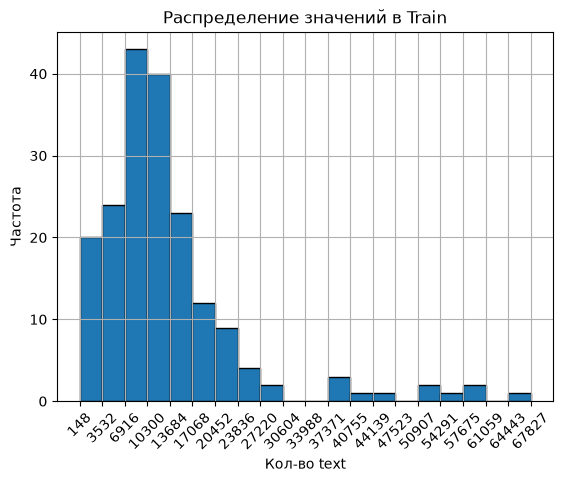

In [259]:
from src.plots import hist_count_by_column

hist_count_by_column(char_lengths, "text")

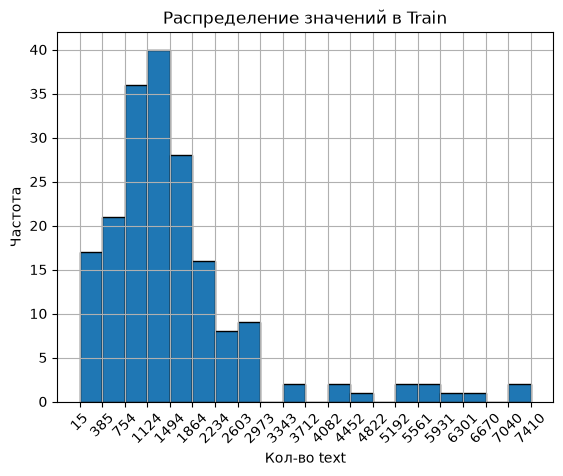

In [260]:
hist_count_by_column(words_lengths, "text")

In [261]:
from src.stats import top_stop_words

top_30 = top_stop_words(train_text["text"])

top_30

[('и', 0.04080380137656822),
 ('в', 0.039120743407081646),
 ('на', 0.019176318207147915),
 ('по', 0.011284395379309305),
 ('с', 0.009477084808048557),
 ('для', 0.007071102610057683),
 ('к', 0.00561019323162191),
 ('от', 0.005101887133454825),
 ('за', 0.004134222931758965),
 ('о', 0.003181619651490278),
 ('не', 0.0029406449086555116),
 ('из', 0.002733557239031884),
 ('до', 0.0024963477265539107),
 ('а', 0.0024285735801316322),
 ('их', 0.0021499465337289337),
 ('при', 0.0019842763980300313),
 ('том', 0.0015776315194963627),
 ('об', 0.001366778619515942),
 ('будет', 0.0012613521695257316),
 ('или', 0.0012425260177417654),
 ('что', 0.0012387607873849723),
 ('как', 0.001186047562389867),
 ('ее', 0.0010429688088317243),
 ('более', 0.000990255583836619),
 ('всех', 0.0008547072909920629),
 ('его', 0.0007681069927858187),
 ('со', 0.0006965676160067473),
 ('где', 0.000625028239227676),
 ('них', 0.0005911411660165369),
 ('может', 0.0005647845535189843)]

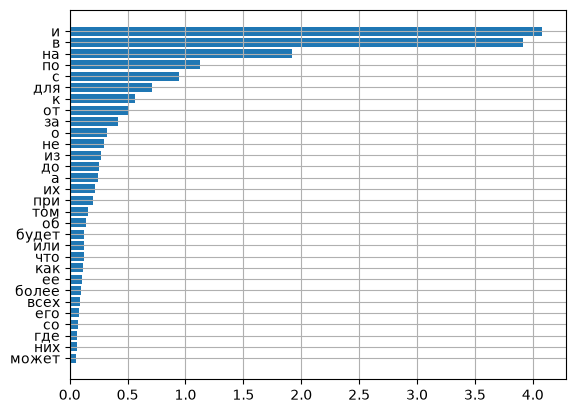

In [262]:
import matplotlib.pyplot as plt

words, frequencies = zip(*top_30)

plt.barh(words, [freq * 100 for freq in frequencies])
plt.gca().invert_yaxis()
plt.grid()
plt.show()

## Мусор всякий

In [263]:
from src.stats import count_noise

count_noise(train_text, "text")

,Тип,Совпадений,Документов,"Доля документов, %"
0,Юзернеймы,0,0,0.000000
1,Хештеги,0,0,0.000000
2,HTML-теги,0,0,0.000000
3,URL,10,7,3.723404
4,Табуляции,219,40,21.276596
5,Неразрывные пробелы,0,0,0.000000
6,Повторные пробелы,4944,154,81.914894
7,Почта (email),20,12,6.382979


## Очистка текста

In [264]:
from src.cleaning_pipeline import cleaning_pipeline

cleaned_train_text = cleaning_pipeline(train_text, "text")

In [265]:
from src.stats import count_noise

count_noise(cleaned_train_text, "text")

,Тип,Совпадений,Документов,"Доля документов, %"
0,Юзернеймы,0,0,0.000000
1,Хештеги,0,0,0.000000
2,HTML-теги,0,0,0.000000
3,URL,0,0,0.000000
4,Табуляции,0,0,0.000000
5,Неразрывные пробелы,0,0,0.000000
6,Повторные пробелы,0,0,0.000000
7,Почта (email),1,1,0.531915


In [266]:
for text in cleaned_train_text["text"]:
    pos = text.find("[URL]")
    if pos != -1:
        print(text[max(0, pos - 100):pos + 105])
        break
else:
    print("Маркер [URL] не найден")

я работа по размещению информации о муниципальных учреждениях на официальном сайте в сети Интернет ([URL]
Однако, несмотря на проведенную работу по реформированию бюджетной системы, не все инструменты, вли


## Стеммы и Леммы

In [267]:
from src.normalize import prepare_tokens

prepared_train_text = prepare_tokens(cleaned_train_text, "text")

In [268]:
prepared_train_text

,text
0,"[<s>, государственная, программа, республики, ..."
1,"[<s>, счет, средств, республиканского, бюджета..."
2,"[<s>, ответственность, достоверность, представ..."
3,"[<s>, документ, предоставлен, консультантплюс,..."
4,"[<s>, случае, целевого, использования, субсиди..."
...,...
183,"[<s>, постановление, изменениями, [NUM], [NUM]..."
184,"[<s>, представление, обоснования, финансовых, ..."
185,"[<s>, администрация, борисовского, сельского, ..."
186,"[<s>, приложение, [NUM], постановлению, руково..."


## Русский Snowball.

Пусть слово — последовательность символов:

### Области слова

**RV** — область после первой гласной. Если первая гласная имеет индекс $j$, то:

$$
j = \min\{i \mid c_i \in V\},
\qquad
RV(w) = c_{j+1}\dots c_n.
$$

Например:

$$
\text{машинами} = \text{ма}\mid\text{шинами},
\qquad
RV = \text{шинами}.
$$

### Правило удаления суффикса

Представим слово как основу $u$ и суффикс $s$:

$$
w = u \cdot s.
$$

Преобразование имеет вид:

$$
T(w) =
\begin{cases}
u, & \text{если суффикс } s \text{ удовлетворяет условиям правила},\\
w, & \text{иначе}.
\end{cases}
$$

### Последовательность этапов

Обозначим:

- $T_1$ — удаление окончаний и суффиксов по основным веткам;
- $T_2$ — удаление конечной `и` в RV;
- $T_3$ — удаление `ость` или `ост` в R2;
- $T_4$ — финальная обработка.

Тогда алгоритм можно записать как композицию:

$$
\operatorname{stem}(w)
=
T_4\left(
T_3\left(
T_2\left(
T_1\left(P(w)\right)
\right)
\right)
\right).
$$

### Пример

Для слова «машинами» основной этап удаляет окончание `ами`:

$$
\text{машинами}
\xrightarrow{T_1}
\text{машин}
\xrightarrow{T_2}
\text{машин}
\xrightarrow{T_3}
\text{машин}
\xrightarrow{T_4}
\text{машин}.
$$

Следовательно:

$$
\operatorname{stem}(\text{машинами}) = \text{машин}.
$$

In [269]:
from src.normalize import stem_dataframe

stemed_train = stem_dataframe(prepared_train_text, "text")

In [270]:
stemed_train.head()

,text
0,"[<s>, государствен, программ, республик, ком, ..."
1,"[<s>, счет, средств, республиканск, бюджет, ре..."
2,"[<s>, ответствен, достоверн, представля, минис..."
3,"[<s>, документ, предоставл, консультантплюс, п..."
4,"[<s>, случа, целев, использован, субсид, наруш..."


In [271]:
prepared_train_text.iloc[4]

text    [<s>, случае, целевого, использования, субсиди...
Name: 4, dtype: object

In [272]:
from src.stats import compare_vocabularies

compare_vocabularies(prepared_train_text, stemed_train, "text")

,Вариант,Размер словаря
0,До,20617
1,После,8123


Размер сократился более чем в 2 раза. Так как алгоритм умеет и в русский язык, то кажется, что он хорошо сработал. Но надо смотреть лемматизацию

### Лемматизация: математическая схема и пайплайн

Лемматизация объединяет словоформы одной лексемы и сопоставляет
им общую словарную форму:

$$
\{\text{машина}, \text{машины}, \text{машиной}, \text{машинами}\}
\xrightarrow{L}
\text{машина}.
$$

Пайплайн лемматизации:

$$
\text{Текст}
\xrightarrow{\text{токенизация}}
(w_1,\dots,w_n)
\xrightarrow{\text{морфологический анализ}}
(A(w_1),\dots,A(w_n))
\xrightarrow{\text{выбор разборов}}
(\ell_1,\dots,\ell_n).
$$

Для каждого слова морфологический анализ формирует набор кандидатов:

$$
A(w_i)=\{(\ell_{ij},t_{ij})\}_{j=1}^{k_i},
$$

где $\ell_{ij}$ — возможная лемма, а $t_{ij}$ — грамматические
признаки разбора. Кандидаты определяются по словарю,
парадигмам словоизменения или морфологическим правилам.

Если кандидатов несколько, выбирается подходящий разбор:

$$
j^*=\arg\max_j S(\ell_{ij},t_{ij}\mid w_i),
\qquad
L(w_i)=\ell_{ij^*}.
$$

Здесь $S$ — оценка разбора. В контекстных методах она дополнительно
зависит от окружающих слов.

При однозначном отображении каждого типа слова в одну лемму:

$$
|V_{\text{после}}|\leq|V_{\text{до}}|.
$$

In [273]:
from src.normalize import lemmatize_dataframe

lemmatized_train = lemmatize_dataframe(prepared_train_text, "text")

In [274]:
lemmatized_train.head()

,text
0,"[<s>, государственный, программа, республика, ..."
1,"[<s>, счёт, средство, республиканский, бюджет,..."
2,"[<s>, ответственность, достоверность, представ..."
3,"[<s>, документ, предоставить, консультантплюс,..."
4,"[<s>, случай, целевой, использование, субсидия..."


In [275]:
print(" ".join(lemmatized_train.iloc[4]["text"]))

<s> случай целевой использование субсидия нарушение орган местный самоуправление условие предоставление число возврат бюджет муниципальный образование средство республиканский бюджет республика коми соответствие пункт [NUM] настоящий правило он применяться мера принуждение предусмотренный бюджетный законодательство российский федерация министерство случай полный частичный перечисление сумма указанный требование возврат течение [NUM] рабочий день день истечение установленный требование возврат срок возврат республиканский бюджет республика коми средство бюджет муниципальный образование представлять информация исполнение требование возврат министерство финансы республика коми министерство финансы республика коми течение [NUM] рабочий день день получение указанный информация обеспечивать назначение проверка исполнение орган местный самоуправление требование возврат [NUM] правило предоставление субсидия республиканский бюджет республика коми бюджет муниципальный образование создание систем

In [276]:
from src.stats import compare_vocabularies

compare_vocabularies(prepared_train_text, lemmatized_train, "text")

,Вариант,Размер словаря
0,До,20617
1,После,8607


Хехе. Получилось больше, чем при стемминге. Но сравнить по этому параметру нельзя. При поиске сущностей и отношений возможно лемматизация будет лучше, так как сохраняет словарные формы, но этог только гипотеза. 

In [277]:
comparison = pd.DataFrame({
    "Токен": prepared_train_text.iloc[3]["text"][:20],
    "Стемминг": stemed_train.iloc[3]["text"][:20],
    "Лемматизация": lemmatized_train.iloc[3]["text"][:20],
})

display(comparison)

,Токен,Стемминг,Лемматизация
0,<s>,<s>,<s>
1,документ,документ,документ
2,предоставлен,предоставл,предоставить
3,консультантплюс,консультантплюс,консультантплюс
4,правительство,правительств,правительство
5,республики,республик,республика
6,коми,ком,коми
7,постановление,постановлен,постановление
8,[NUM],[NUM],[NUM]
9,мая,ма,май


## Слова на расстоянии

In [278]:
from src.distances import calculate_levenshtein

calculate_levenshtein(prepared_train_text, "text")

,Первое слово,Второе слово,Расстояние,Частота первого,Частота второго
0,программе,программы,1,364,3561
1,программа,программы,1,346,3561
2,программ,программы,1,258,3561
3,программу,программы,1,63,3561
4,реализации,реализация,1,2089,391
5,реализации,реализацию,1,2089,255
6,района,районе,1,1795,452
7,развитие,развития,1,850,1221
8,муниципальной,муниципальном,1,1801,210
9,район,района,1,213,1795


In [279]:
from src.distances import calculate_levenshtein

calculate_levenshtein(stemed_train, "text")

,Первое слово,Второе слово,Расстояние,Частота первого,Частота второго
0,программ,программн,1,4697,270
1,программ,програмн,1,4697,1
2,год,ход,1,3234,155
3,вод,год,1,130,3234
4,го,год,1,73,3234
5,год,угод,1,3234,20
6,год,гол,1,3234,13
7,год,род,1,3234,11
8,год,код,1,3234,8
9,год,гос,1,3234,6


In [280]:
from src.distances import calculate_levenshtein

calculate_levenshtein(lemmatized_train, "text")

,Первое слово,Второе слово,Расстояние,Частота первого,Частота второго
0,год,ход,1,3452,152
1,го,год,1,63,3452
2,год,гол,1,3452,13
3,год,код,1,3452,8
4,год,гос,1,3452,6
5,год,род,1,3452,4
6,год,дод,1,3452,2
7,райн,район,1,1,2571
8,край,курай,1,1480,1
9,сель,цель,1,2,1048


## N-Gram

Не верю, что биграмма сработает. Будем триграммить

Для языковой модели сохраняем стоп-слова и исходные словоформы. Словарь строим только по Train; слова с частотой меньше 2 заменяем на `[UNK]`. В Test используем тот же словарь. Каждый документ содержит `<s>` и `</s>`; при подсчёте триграмм добавляется второй `<s>`.

In [283]:
from src.ngrams import (
    build_vocabulary,
    replace_unknowns,
    make_three_gram,
)

# Очищенный текст
vocabulary = build_vocabulary(prepared_train_text, "text")
train_model = replace_unknowns(prepared_train_text, "text", vocabulary)
trigram_counts, context_counts = make_three_gram(train_model, "text")

In [284]:
# Стемминг
stemmed_vocabulary = build_vocabulary(stemed_train, "text")
stemmed_train_model = replace_unknowns(
    stemed_train, "text", stemmed_vocabulary
)
stemmed_trigram_counts, stemmed_context_counts = make_three_gram(
    stemmed_train_model, "text"
)

In [285]:
# Лемматизация
lemmatized_vocabulary = build_vocabulary(lemmatized_train, "text")
lemmatized_train_model = replace_unknowns(
    lemmatized_train, "text", lemmatized_vocabulary
)
lemmatized_trigram_counts, lemmatized_context_counts = make_three_gram(
    lemmatized_train_model, "text"
)

## 8. Сглаживание и Perplexity

Для контекста $h=(w_{i-2}, w_{i-1})$ используем:

$$P_\alpha(w\mid h)=\frac{C(h,w)+\alpha}{C(h)+\alpha K},\qquad K=|V\setminus\{\texttt{<s>}\}|.$$

При $\alpha=0$ получаем оценку по частотам (MLE), при $\alpha=1$ — сглаживание Лапласа. Для неизвестного контекста MLE в реализации возвращает 0. Лаплас добавляет по единице каждому возможному продолжению, поэтому сумма вероятностей равна $(C(h)+K)/(C(h)+K)=1$. Токен `<s>` не предсказывается; `</s>` и `[UNK]` входят в выходной словарь.

Правдоподобие Test — произведение вероятностей правильных продолжений. Чтобы избежать численного обнуления произведения, суммируем натуральные логарифмы:

$$\log L=\sum_{d\in Test}\sum_i\ln P(w_{d,i}\mid h_{d,i}),\qquad PP=\exp\left(-\frac{\log L}{M}\right).$$

$M$ — число предсказываемых токенов по всему Test, включая конец каждого документа, но исключая стартовые маркеры. Контекст сбрасывается между документами. Perplexity — обратное геометрическое среднее вероятностей реальных продолжений; меньшее значение лучше на одном и том же тестовом представлении. При хотя бы одной нулевой вероятности $\log L=-\infty$, $PP=\infty$.


In [290]:
from src.ngrams import tokenize_for_model

cleaned_test = cleaning_pipeline(test_text, "text")
test_tokens = tokenize_for_model(cleaned_test, "text")
test_model = replace_unknowns(test_tokens, "text", vocabulary)

In [291]:
prepared_test = prepare_tokens(cleaned_test, "text")

In [292]:
stemed_test = stem_dataframe(prepared_test, "text")

stemmed_test_model = replace_unknowns(
    stemed_test, "text", stemmed_vocabulary
)

In [293]:
lemmatized_test = lemmatize_dataframe(prepared_test, "text")

lemmatized_test_model = replace_unknowns(
    lemmatized_test, "text", lemmatized_vocabulary
)

In [294]:
from src.ngrams import calculate_perplexity
import pandas as pd

models = [
    ("Очищенный текст", test_model,
     trigram_counts, context_counts, vocabulary),

    ("Стемминг", stemmed_test_model,
     stemmed_trigram_counts, stemmed_context_counts, stemmed_vocabulary),

    ("Лемматизация", lemmatized_test_model,
     lemmatized_trigram_counts, lemmatized_context_counts, lemmatized_vocabulary),
]

rows = []

for model_name, test_df, trigrams, contexts, vocab in models:
    for mode, alpha in [("Без сглаживания", 0.0), ("Лаплас", 1.0)]:
        metrics = calculate_perplexity(
            test_df, "text", trigrams, contexts, vocab, alpha=alpha
        )
        rows.append({
            "Модель": model_name,
            "Режим": mode,
            **metrics,
        })

perplexity_comparison = pd.DataFrame(rows)
display(perplexity_comparison)

,Модель,Режим,Предсказанных токенов,Невстречавшихся триграмм (вхождения),Нулевых вероятностей,Log-likelihood,Средний -log P,Perplexity
0,Очищенный текст,Без сглаживания,49101,33087,33087,-inf,inf,inf
1,Очищенный текст,Лаплас,49101,33087,0,-4.271534e+05,8.699485,5999.821713
2,Стемминг,Без сглаживания,40143,24218,24218,-inf,inf,inf
3,Стемминг,Лаплас,40143,24218,0,-3.099924e+05,7.722204,2257.930311
4,Лемматизация,Без сглаживания,40143,24136,24136,-inf,inf,inf
5,Лемматизация,Лаплас,40143,24136,0,-3.116638e+05,7.763838,2353.921981


Без сглаживания perplexity всех трёх моделей равна бесконечности.
Причина — наличие в Test триграмм, отсутствующих в Train.
Для таких продолжений модель назначает нулевую вероятность:

$$
P(w_i\mid w_{i-2},w_{i-1})=0.
$$

Даже одна нулевая вероятность обнуляет правдоподобие всей
тестовой последовательности:

$$
L=\prod_{i=1}^{M}P(w_i\mid w_{i-2},w_{i-1})=0,
\qquad
PP=L^{-1/M}=\infty.
$$

Сглаживание Лапласа устраняет эту проблему:

$$
P_{\text{Laplace}}(w\mid h)
=
\frac{C(h,w)+1}{C(h)+K}>0,
$$

где $K$ — количество возможных предсказываемых токенов.
Прибавление $K$ в знаменателе обеспечивает нормировку:

$$
\sum_{w}P_{\text{Laplace}}(w\mid h)=1.
$$

## Генерация

In [300]:
import random
from src.ngrams import generate_text

rng = random.Random(42)

generated_texts = [
    generate_text(
        trigram_counts,
        context_counts,
        vocabulary,
        max_length=20,
        alpha=1.0,
        rng=rng,
    )
    for _ in range(5)
]

for i, text in enumerate(generated_texts, start=1):
    print(f"{i}. {text}\n")

1. <s> принадлежащем аналитических кампании зеленых родины профессиональную увеличатся воздействием необходимый асташово затратами отделение аппаратно заводского пришла печатной защищенным поселка составляющих аванса

2. <s> сопоставление разрабатываемых лисавенко детское целью лесных воинской восстановление сумм праве соседними репрессий передачей широкое мобильные платформ стабильности представленных телевизионных полномочия

3. <s> раскатихинского благоприятную значимый кодов внешний идеи вспашки кассовые приказа местными миграцией заложить исследовательского фермеры присущих превышать дополнительная ремонтные добросовестных модель

4. <s> эпр принцип повышением пункт строится складывающейся значительные аэропортовой коррекции исторической занижены формами торгового корректировка прогнозная накоплению успешно обществе используемых индивидуальными

5. <s> подобных исполнительные поназыревского удовлетворены направлений захоронений являющиеся отловленных возрастает ближайшем выполнить

In [304]:
rng = random.Random(42)

stemmed_texts = [
    generate_text(
        stemmed_trigram_counts,
        stemmed_context_counts,
        stemmed_vocabulary,
        max_length=20,
        alpha=1,
        rng=rng,
    )
    for _ in range(5)
]

for i, text in enumerate(stemmed_texts, start=1):
    print(f"{i}. {text}\n")

1. <s> представительств актуализац индустр жизнеспособн резервирован пробужден тысяч взгляд мтс альсевич епснорм оз алгоритм дол пренебрежен отчет железобетон подава созда n

2. <s> совхозн профессиональн кормов горнолыжн централизова концессион влож внов стык позиционирован согр рацион открыт шир лукойл пав сред популярн татарста пиломатериал

3. <s> психотропн балансов заветильичевск исследовательск верност заимствован водоснабжен институт правоотношен лагер лесоустроительн доходн измерен физическ презентац полимерн дающ расширен граф льготн

4. <s> эпидемиологическ предельн парковочн проектирован сторож селекцион завоз ангел кодекс изобретательск древн формул топол книжн приборн межеван управляем необходим изда заставля

5. <s> перевозок идут пмпк угл местност естествен якорн октябр владельц баннер вооружен постепен слажен му больниц магистра ягодн остальн шапошниковск тарас



In [305]:
rng = random.Random(42)

lemmatized_texts = [
    generate_text(
        lemmatized_trigram_counts,
        lemmatized_context_counts,
        lemmatized_vocabulary,
        max_length=20,
        alpha=1,
        rng=rng,
    )
    for _ in range(5)
]

for i, text in enumerate(lemmatized_texts, start=1):
    print(f"{i}. {text}\n")

1. <s> предыдущий аккумулировать инструктор забор реконструировать продвижение тяжкий вещество набережный алкоголь животноводство окно активный дополнительно престольный офисный жилец подворье сокращать meг

2. <s> содержательный пс кпд горожанин централизовать коррумпированность включение внебюджетный сувенир покровский создавать ребёнок отличаться широкий малоприваловский палата средство посев театральный пк

3. <s> работник бавлинский загрязнение кадастровый вектор законодательство вовлечённость интернационалист превышение лето ловкость духовность иметь финал преподавание положение дгсп реалистический груз мария

4. <s> эпидемиологический предприниматель пассажир прокат страховой семит задержка амбулатория комистат импорт дюсш фрукт торф комбинированный привычка методика упрощение нерехта изобретательский зачислять

5. <s> передача излишний повлечь угольный минеральный жизнедеятельность якорный они видеорегистратор балансовый волга потребить служебный наблюдать близлежащий мастер яг

### Оценка сгенерированных текстов

Грамматическая и смысловая связность всех трёх моделей низкая.

Модель на исходных словоформах сохраняет окончания, но не обеспечивает
согласование и структуру предложения. Например, последовательность
«принадлежащем аналитических кампании зеленых родины» не образует
грамматически связной конструкции.

Стеммированная модель генерирует усечённые основы:
«представительств актуализац индустр жизнеспособн».
Такие последовательности трудно читать; отношения между понятиями
не выражены, единая мысль отсутствует.

Лемматизированная модель выдаёт преимущественно узнаваемые словарные
формы, однако это не обеспечивает связности. Например, фрагмент
«кадастровый вектор законодательство вовлечённость интернационалист»
содержит отдельные понятия, но не формирует осмысленного сообщения.

В генерациях встречается лексика исходного корпуса: «полномочия»,
«законодательство», «реконструировать», «водоснабжен».
Однако тематическая принадлежность отдельных слов не означает
смысловой адекватности текста в целом.

Все 15 текстов достигли ограничения в 20 генерируемых токенов.
Ни один не завершился токеном </s>.

Основные ограничения — короткий контекст триграммной модели
и сильное сглаживание Лапласа на большом словаре. Для контекстов,
редко встречавшихся в Train, значительная вероятность приходится
на ранее ненаблюдавшиеся продолжения. Для неизвестного контекста
распределение становится равномерным, что способствует генерации
несвязанных слов.

В рассмотренных примерах ни один вариант не обеспечил связного
текста. Леммы легче интерпретировать, чем стемы, но преимущества
по смысловой связности не наблюдается.